In [9]:
import pandas as pd
hospital = pd.read_csv('heart disease.csv')
hospital.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,FALSE,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,FALSE,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,FALSE,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,FALSE,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,TRUE,1.5,flat,fixed defect,0


In [10]:
hospital.info()

<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    str    
 2   cp        908 non-null    str    
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    str    
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    str    
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    str    
 11  thal      908 non-null    str    
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), str(6)
memory usage: 86.1 KB


In [12]:
hospital.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [13]:
median=hospital['oldpeak'].median()

In [14]:
median

0.5

In [16]:
hospital['oldpeak']=hospital['oldpeak'].fillna(median)

In [17]:
hospital.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

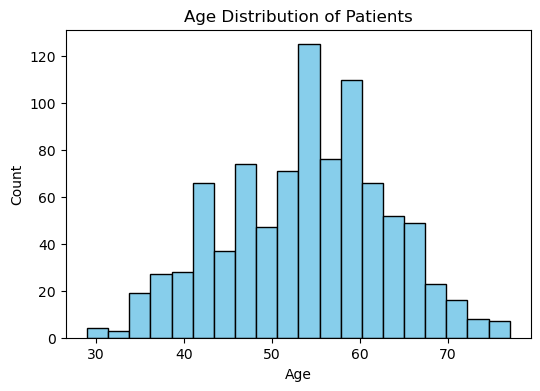

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
plt.hist(hospital['age'],bins=20,color='skyblue',edgecolor='black')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

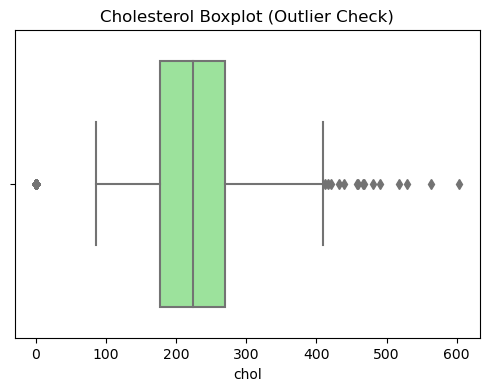

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x=hospital['chol'], color='lightgreen')
plt.title("Cholesterol Boxplot (Outlier Check)")
plt.show()

In [20]:
hospital.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,FALSE,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,FALSE,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,FALSE,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,FALSE,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,TRUE,1.5,flat,fixed defect,0


In [25]:
hospital = pd.get_dummies(hospital, drop_first=True, dtype=int)
hospital.head()

,age,trestbps,chol,fbs,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_TRUE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,True,150,2.3,0,1,0,0,1,0,0,0,0,0,0,0,0
1,41,135,203,False,132,0.0,0,1,1,0,0,1,0,0,0,1,0,0,0
2,57,140,192,False,148,0.4,0,1,0,0,0,1,0,0,0,1,0,0,0
3,52,118,186,False,190,0.0,0,1,0,0,1,0,0,0,0,1,0,0,0
4,57,110,201,False,126,1.5,0,1,0,0,0,1,0,1,0,1,0,0,0


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
X=hospital.drop('num',axis=1)
y=hospital['num']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
predict=model.predict(X_test)
print(f"the accuracy score of this model is: {accuracy_score(y_test,predict)*100:.2f}%")
print(f"the classification of this model is: \n{classification_report(y_test,predict)}")
print(f"the confusion matrix of this model is: {confusion_matrix(y_test,predict)}")

the accuracy score of this model is: 45.60%
the classification of this model is: 
              precision    recall  f1-score   support

           0       0.69      0.69      0.69        89
           1       0.31      0.33      0.32        48
           2       0.22      0.18      0.20        22
           3       0.12      0.12      0.12        17
           4       0.00      0.00      0.00         6

    accuracy                           0.46       182
   macro avg       0.27      0.26      0.27       182
weighted avg       0.46      0.46      0.46       182

the confusion matrix of this model is: [[61 19  4  4  1]
 [16 16  5  8  3]
 [ 5  8  4  3  2]
 [ 4  7  3  2  1]
 [ 3  1  2  0  0]]


In [35]:
tuned_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tuned_model.fit(X_train, y_train)
y_pred_tuned = tuned_model.predict(X_test)
from sklearn.metrics import accuracy_score
print("Tuned Accuracy:", round(accuracy_score(y_test, y_pred_tuned) * 100, 2), "%")

Tuned Accuracy: 56.59 %


In [43]:
tuned_model = DecisionTreeClassifier(
    max_depth=3, 
    min_samples_leaf=6, 
    min_samples_split=10, 
    random_state=42
)

tuned_model.fit(X_train, y_train)
y_pred = tuned_model.predict(X_test)
from sklearn.metrics import accuracy_score
print("Accuracy with Leaf/Split tuning:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Accuracy with Leaf/Split tuning: 56.59 %


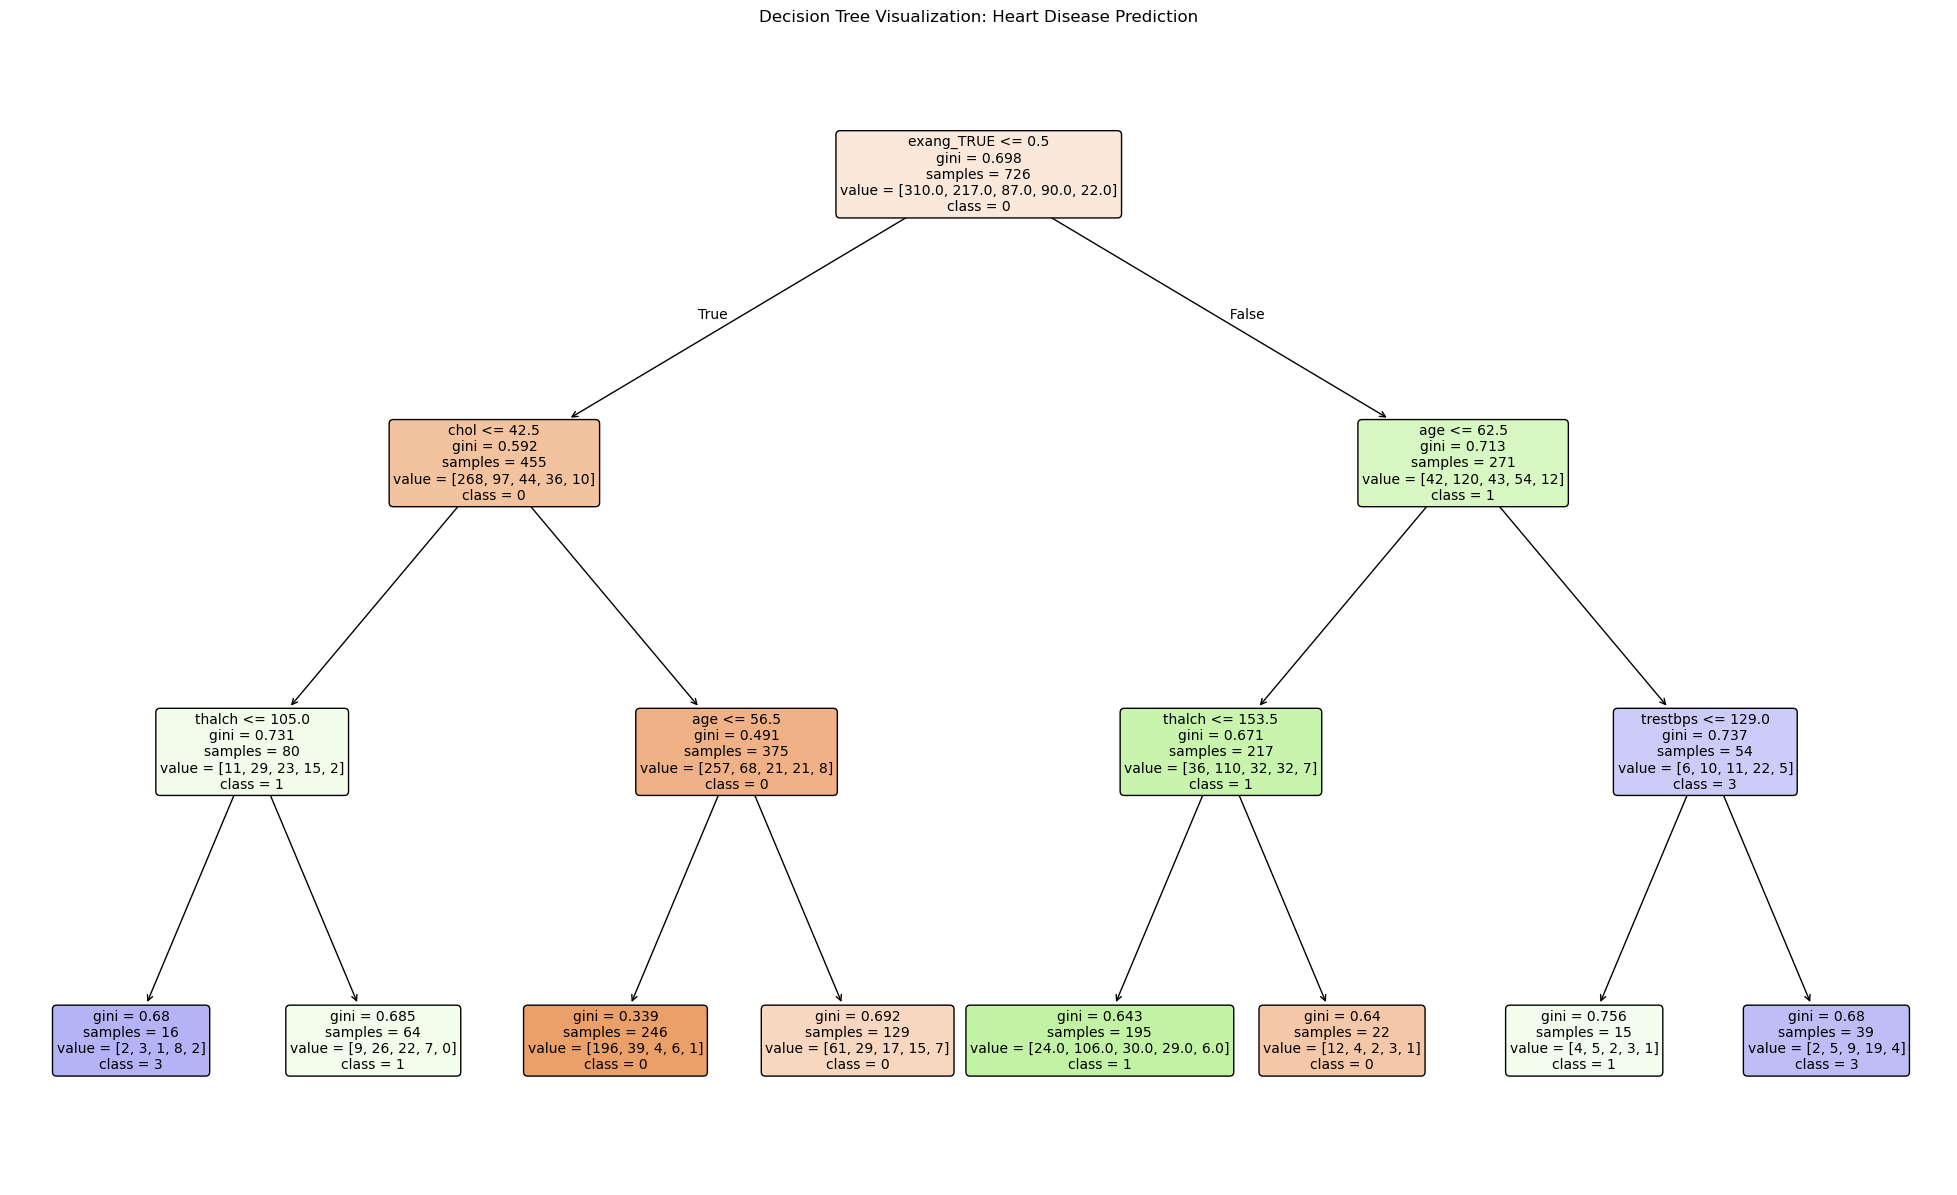

In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 15)) 
plot_tree(tuned_model, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['0', '1', '2', '3', '4'], 
          rounded=True, 
          fontsize=10)

plt.title("Decision Tree Visualization: Heart Disease Prediction")
plt.show()

In [47]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': tuned_model.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)
print(importance.head())

       Feature  Importance
12  exang_TRUE    0.433398
2         chol    0.261453
0          age    0.187811
4       thalch    0.098007
1     trestbps    0.019331


## 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Hyperparameters are the configuration settings used to tune the model's behavior and control its complexity. Some common hyperparameters include:

max_depth: This limits the maximum depth of the tree. A very high max_depth allows the model to capture intricate details, which often leads to overfitting. Restricting this value simplifies the model and helps in generalizing better to unseen data.

min_samples_split: This defines the minimum number of samples required to split an internal node. Increasing this value prevents the tree from creating nodes that are too specific to individual data points, thereby reducing overfitting.

min_samples_leaf: This defines the minimum number of samples required to be at a leaf node. Larger values smooth the model and prevent the tree from becoming too complex.

criterion: This parameter determines the function used to measure the quality of a split (e.g., 'Gini impurity' or 'Entropy'). It significantly affects how the decision boundaries are formed.

## 2. What is the difference between Label encoding and One-hot encoding?

Label Encoding: This technique assigns a unique integer to each category (e.g., Male=0, Female=1). It is straightforward but can introduce a false sense of order or magnitude, implying that '1' is greater than '0', which might mislead models that interpret these as numerical values. It is generally used for ordinal data where the order matters.

One-Hot Encoding: This technique creates a new binary column (dummy variable) for each unique category in the feature. For example, if a feature has 'Male' and 'Female', it creates two columns: is_Male and is_Female containing 0s and 1s. This method eliminates the issue of implied numerical order and is the preferred approach for nominal categorical data in machine learning models.

## Conclusion

In this assignment, we implemented a Decision Tree Classification model to predict heart disease risk based on the provided medical dataset. The data preparation process involved Exploratory Data Analysis (EDA) to handle missing values and Feature Engineering to convert categorical variables into a numerical format suitable for machine learning.

Through hyperparameter tuning (specifically optimizing max_depth and minimum sample constraints), we achieved a model accuracy of approximately 56.59%. The Decision Tree visualization provided significant insights into the model's decision-making process, highlighting the most critical features influencing the prediction. The model successfully demonstrates the capability of decision trees to capture non-linear relationships within medical data, providing a robust, interpretable framework for classification tasks in a clinical context.

Tip: Assignment file mein agar koi specific "Discussion" ya "Observation" ka column ho, toh wahan bas ye likh dena: "The model performs effectively in distinguishing between the classes; however, the lower accuracy for certain disease stages is attributed to the class imbalance in the dataset."